In [1]:
#03 31 2026 Option market distribution cdf vs pdf .
import yfinance as yf
import pandas as pd
ticker = yf.Ticker("AAPL")

exp = ticker.options[0]  # nearest expiration
chain = ticker.option_chain(exp)

calls = chain.calls
puts = chain.puts

# Calculate volumes
call_volume = calls['volume'].sum()
put_volume = puts['volume'].sum()

print("Call volume:", call_volume)
print("Put volume:", put_volume)
print("Total volume:", call_volume + put_volume)


Call volume: 487540.0
Put volume: 120924.0
Total volume: 608464.0


In [ ]:
#What are the parameters usually?

In [ ]:
!pip install yfinance

In [ ]:
#data for today.
import yfinance as yf
import pandas as pd

ticker = yf.Ticker("AAPL")

total_call_volume = 0
total_put_volume = 0
rows = []

for exp in ticker.options:
    chain = ticker.option_chain(exp)
    calls = chain.calls.copy()
    puts = chain.puts.copy()

    call_volume = pd.to_numeric(calls["volume"], errors="coerce").fillna(0).sum()
    put_volume = pd.to_numeric(puts["volume"], errors="coerce").fillna(0).sum()

    total_call_volume += call_volume
    total_put_volume += put_volume

    rows.append({
        "expiration": exp,
        "call_volume": int(call_volume),
        "put_volume": int(put_volume),
        "total_volume": int(call_volume + put_volume)
    })

summary_df = pd.DataFrame(rows)

print(summary_df)
print()
print("Total call volume:", int(total_call_volume))
print("Total put volume:", int(total_put_volume))
print("Grand total option volume:", int(total_call_volume + total_put_volume))

    expiration  call_volume  put_volume  total_volume
0   2026-05-06       368435      121346        489781
1   2026-05-08       221237       71012        292249
2   2026-05-11        27126        8528         35654
3   2026-05-13        11463        1560         13023
4   2026-05-15        98274       41422        139696
5   2026-05-22        13793        5310         19103
6   2026-05-29        16162        3365         19527
7   2026-06-05        16263        9590         25853
8   2026-06-12         3867        1103          4970
9   2026-06-18        57049       17209         74258
10  2026-07-17        26288       15320         41608
11  2026-08-21        13457       23194         36651
12  2026-09-18        13217        4852         18069
13  2026-10-16         4948        4706          9654
14  2026-11-20         1963        1560          3523
15  2026-12-18         8075        5138         13213
16  2027-01-15         8454        4646         13100
17  2027-03-19         2312 

In [ ]:
#Open, High, Low, Close, Volume

In [ ]:
hist = ticker.history(period="1y")
print(hist.head())

In [ ]:
import yfinance as yf

ticker = yf.Ticker("AAPL")

# available expiration dates
dates = ticker.options
print(dates)

# get option chain for one expiration date
chain = ticker.option_chain(dates[0])

calls = chain.calls
puts = chain.puts

print(calls.head())
print(puts.head())


('2026-05-06', '2026-05-08', '2026-05-11', '2026-05-13', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
        contractSymbol             lastTradeDate  strike  lastPrice    bid  \
0  AAPL260506C00215000 2026-05-06 18:50:36+00:00   215.0      72.07  70.85   
1  AAPL260506C00220000 2026-05-06 18:50:36+00:00   220.0      67.17  65.90   
2  AAPL260506C00235000 2026-05-06 18:51:43+00:00   235.0      52.27  50.80   
3  AAPL260506C00242500 2026-05-06 19:29:54+00:00   242.5      45.30  43.80   
4  AAPL260506C00245000 2026-05-06 16:30:27+00:00   245.0      41.50  41.15   

    ask     change  percentChange  volume  openInterest  impliedVolatility  \
0  74.4   4.900002       7.294926      31             8           2.414066   
1  69.4   7.219997      12.043366      24           

Index(['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask',
       'change', 'percentChange', 'volume', 'openInterest',
       'impliedVolatility', 'inTheMoney', 'contractSize', 'currency'],
      dtype='object')

In [ ]:
calls.columns

#Option related data that is important:
#strike              # option strike price
#lastPrice           # m  ost recent traded option price
#bid / ask           # market quotes
#impliedVolatility   # market-implied volatility
#volume              # trading activity
#openInterest        # existing contracts outstanding
#inTheMoney          # whether option is ITM
#lastTradeDate       # last transaction time
#contractSymbol      # option identifier

Index(['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask',
       'change', 'percentChange', 'volume', 'openInterest',
       'impliedVolatility', 'inTheMoney', 'contractSize', 'currency'],
      dtype='object')

In [ ]:
#data for today.
ticker = yf.Ticker("AAPL")

all_contracts = []

for exp in ticker.options:
    chain = ticker.option_chain(exp)

    calls = chain.calls.copy()
    calls["side"] = "call"
    calls["expiration"] = exp

    puts = chain.puts.copy()
    puts["side"] = "put"
    puts["expiration"] = exp

    all_contracts.append(calls)
    all_contracts.append(puts)

df = pd.concat(all_contracts, ignore_index=True)

df["volume"] = pd.to_numeric(df["volume"], errors="coerce").fillna(0)
df["openInterest"] = pd.to_numeric(df["openInterest"], errors="coerce").fillna(0)

top = df.sort_values("volume", ascending=False)[
    ["contractSymbol", "side", "expiration", "strike", "volume", "openInterest", "impliedVolatility", "lastPrice"]
].head(20)

print(top.to_string(index=False))

     contractSymbol side expiration  strike   volume  openInterest  impliedVolatility  lastPrice
AAPL260506C00287500 call 2026-05-06   287.5 147318.0          9313           0.000010       0.19
AAPL260506C00285000 call 2026-05-06   285.0  95951.0         11219           0.000010       2.09
AAPL260506C00290000 call 2026-05-06   290.0  50161.0         10942           0.085947       0.01
AAPL260506P00285000  put 2026-05-06   285.0  42975.0          3475           0.107431       0.03
AAPL260508C00290000 call 2026-05-08   290.0  40805.0         19844           0.208260       1.20
AAPL260508C00285000 call 2026-05-08   285.0  30888.0         11160           0.188485       3.50
AAPL260508C00287500 call 2026-05-08   287.5  25460.0         11430           0.201180       2.19
AAPL260506P00282500  put 2026-05-06   282.5  25318.0          4408           0.156258       0.01
AAPL260508C00295000 call 2026-05-08   295.0  23958.0         17878           0.229988       0.33
AAPL260618C00300000 call 2026-

In [ ]:
#data for today
import yfinance as yf
import pandas as pd

ticker = yf.Ticker("AAPL")

all_contracts = []

for exp in ticker.options:
    chain = ticker.option_chain(exp)

    calls = chain.calls.copy()
    calls["side"] = "call"
    calls["expiration"] = exp

    puts = chain.puts.copy()
    puts["side"] = "put"
    puts["expiration"] = exp

    all_contracts.append(calls)
    all_contracts.append(puts)

df = pd.concat(all_contracts, ignore_index=True)

df["volume"] = pd.to_numeric(df["volume"], errors="coerce").fillna(0)
df["openInterest"] = pd.to_numeric(df["openInterest"], errors="coerce").fillna(0)

top = df.sort_values("volume", ascending=False)[
    ["contractSymbol", "side", "expiration", "strike", "volume", "openInterest", "impliedVolatility", "lastPrice"]
].head(20)
print(top.to_string(index=False))

     contractSymbol side expiration  strike   volume  openInterest  impliedVolatility  lastPrice
AAPL260506C00287500 call 2026-05-06   287.5 147318.0          9313           0.000010       0.19
AAPL260506C00285000 call 2026-05-06   285.0  95951.0         11219           0.000010       2.09
AAPL260506C00290000 call 2026-05-06   290.0  50161.0         10942           0.085947       0.01
AAPL260506P00285000  put 2026-05-06   285.0  42975.0          3475           0.107431       0.03
AAPL260508C00290000 call 2026-05-08   290.0  40805.0         19844           0.208260       1.20
AAPL260508C00285000 call 2026-05-08   285.0  30888.0         11160           0.188485       3.50
AAPL260508C00287500 call 2026-05-08   287.5  25460.0         11430           0.201180       2.19
AAPL260506P00282500  put 2026-05-06   282.5  25318.0          4408           0.156258       0.01
AAPL260508C00295000 call 2026-05-08   295.0  23958.0         17878           0.229988       0.33
AAPL260618C00300000 call 2026-

In [ ]:
#- intraday vs 5 day average.
import os
from datetime import datetime
import yfinance as yf
import pandas as pd

SYMBOL = "AAPL"
CSV_FILE = f"{SYMBOL}_option_volume_history.csv"


def get_today_option_volume(symbol: str):
    ticker = yf.Ticker(symbol)

    total_call_volume = 0
    total_put_volume = 0

    expirations = ticker.options
    if not expirations:
        raise ValueError(f"No option expirations found for {symbol}")

    for exp in expirations:
        chain = ticker.option_chain(exp)

        calls = chain.calls.copy()
        puts = chain.puts.copy()

        call_volume = pd.to_numeric(calls["volume"], errors="coerce").fillna(0).sum()
        put_volume = pd.to_numeric(puts["volume"], errors="coerce").fillna(0).sum()

        total_call_volume += call_volume
        total_put_volume += put_volume

    return {
        "date": pd.Timestamp.today().normalize(),
        "symbol": symbol,
        "call_volume": int(total_call_volume),
        "put_volume": int(total_put_volume),
        "total_volume": int(total_call_volume + total_put_volume),
    }


def load_history(csv_file: str):
    if os.path.exists(csv_file):
        df = pd.read_csv(csv_file, parse_dates=["date"])
        return df
    return pd.DataFrame(columns=["date", "symbol", "call_volume", "put_volume", "total_volume"])


def upsert_today(history_df: pd.DataFrame, today_row: dict):
    today_date = pd.to_datetime(today_row["date"])

    # remove existing row for today if script is rerun
    if not history_df.empty:
        history_df = history_df[history_df["date"] != today_date]

    updated_df = pd.concat([history_df, pd.DataFrame([today_row])], ignore_index=True)
    updated_df = updated_df.sort_values("date").reset_index(drop=True)
    return updated_df


def compute_5day_stats(df: pd.DataFrame):
    df = df.sort_values("date").reset_index(drop=True)

    # 5-day average excluding today
    df["five_day_avg"] = df["total_volume"].shift(1).rolling(5).mean()

    # compare today to prior 5-day average
    df["pct_vs_5day_avg"] = (
        (df["total_volume"] - df["five_day_avg"]) / df["five_day_avg"] * 100
    )

    return df


def main():
    today_data = get_today_option_volume(SYMBOL)
    history_df = load_history(CSV_FILE)
    history_df = upsert_today(history_df, today_data)
    history_df = compute_5day_stats(history_df)

    history_df.to_csv(CSV_FILE, index=False)

    latest = history_df.iloc[-1]

    print(f"\nSymbol: {SYMBOL}")
    print(f"Date: {latest['date'].date()}")
    print(f"Today's call volume: {int(latest['call_volume']):,}")
    print(f"Today's put volume: {int(latest['put_volume']):,}")
    print(f"Today's total option volume: {int(latest['total_volume']):,}")

    if pd.notna(latest["five_day_avg"]):
        print(f"Previous 5-day average total volume: {latest['five_day_avg']:,.2f}")
        print(f"Today's volume vs 5-day average: {latest['pct_vs_5day_avg']:.2f}%")

        if latest["pct_vs_5day_avg"] > 20:
            print("Signal: Today's option volume is notably ABOVE the 5-day average.")
        elif latest["pct_vs_5day_avg"] < -20:
            print("Signal: Today's option volume is notably BELOW the 5-day average.")
        else:
            print("Signal: Today's option volume is roughly in line with the 5-day average.")
    else:
        print("Not enough prior data yet to compute a 5-day average.")
        print("Run this script daily until at least 6 total trading days are logged.")

    print(f"\nSaved history to: {CSV_FILE}")
    print("\nRecent history:")
    print(history_df.tail(10).to_string(index=False))


if __name__ == "__main__":
    main()


Symbol: AAPL
Date: 2026-05-06
Today's call volume: 800,954
Today's put volume: 315,281
Today's total option volume: 1,116,235
Not enough prior data yet to compute a 5-day average.
Run this script daily until at least 6 total trading days are logged.

Saved history to: AAPL_option_volume_history.csv

Recent history:
      date symbol call_volume put_volume total_volume  five_day_avg pct_vs_5day_avg
2026-05-06   AAPL      800954     315281      1116235           NaN             NaN


/tmp/ipykernel_1583/2358750469.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  updated_df = pd.concat([history_df, pd.DataFrame([today_row])], ignore_index=True)


In [ ]:
#in this case, marketdata
#For MarketData could be better .

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta

TOKEN = "RDJQOXJ5dmNjT2tEZTRoN21PbFpUVkFjZVZxTGZKamhnVWRNaTBzOWJyYz0"
SYMBOL = "AAPL"
BASE_URL = "https://api.marketdata.app/v1/options/chain"

def get_last_n_weekdays(n: int, end_date: datetime | None = None):
    """
    Return the last n weekdays ending at end_date (default: today).
    This is a simple weekday filter, not a full US market holiday calendar.
    """
    if end_date is None:
        end_date = datetime.today()

    dates = []
    cur = end_date

    while len(dates) < n:
        if cur.weekday() < 5:  # Mon-Fri
            dates.append(cur.strftime("%Y-%m-%d"))
        cur -= timedelta(days=1)

    return sorted(dates)

def fetch_chain_for_date(symbol: str, date_str: str, token: str):
    """
    Fetch historical end-of-day option chain for a given symbol/date.
    Docs: GET /v1/options/chain/{underlyingSymbol}/?date=YYYY-MM-DD
    """
    url = f"{BASE_URL}/{symbol}/"
    headers = {
        "Accept": "application/json",
        "Authorization": f"Bearer {token}",
    }
    params = {
        "date": date_str,
    }

    r = requests.get(url, headers=headers, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    if data.get("s") != "ok":
        raise ValueError(f"API returned non-ok status for {date_str}: {data}")

    return data

def chain_json_to_dataframe(data: dict) -> pd.DataFrame:
    """
    MarketData chain responses are column-oriented arrays.
    Build a DataFrame from the keys that are present.
    """
    # Keep only list-like fields with matching lengths
    list_fields = {}
    target_len = None

    for k, v in data.items():
        if isinstance(v, list):
            if target_len is None:
                target_len = len(v)
            if len(v) == target_len:
                list_fields[k] = v

    if not list_fields:
        return pd.DataFrame()

    df = pd.DataFrame(list_fields)
    return df

def summarize_chain(df: pd.DataFrame, date_str: str) -> dict:
    """
    Sum call and put volume across the whole chain for that historical date.
    """
    if df.empty:
        return {
            "date": date_str,
            "call_volume": 0,
            "put_volume": 0,
            "total_volume": 0,
            "contracts": 0,
        }

    # Standard fields from docs include side and volume
    if "volume" not in df.columns or "side" not in df.columns:
        raise ValueError(f"Expected 'volume' and 'side' columns, got: {df.columns.tolist()}")

    df["volume"] = pd.to_numeric(df["volume"], errors="coerce").fillna(0)
    df["side"] = df["side"].astype(str).str.lower()

    call_volume = df.loc[df["side"] == "call", "volume"].sum()
    put_volume = df.loc[df["side"] == "put", "volume"].sum()

    return {
        "date": date_str,
        "call_volume": int(call_volume),
        "put_volume": int(put_volume),
        "total_volume": int(call_volume + put_volume),
        "contracts": int(len(df)),
    }

def main():
    # Free plan is at least 24h delayed, so using recent prior weekdays makes more sense.
    # You can adjust this as needed.
    dates = get_last_n_weekdays(5)

    rows = []
    for d in dates:
        try:
            raw = fetch_chain_for_date(SYMBOL, d, TOKEN)
            df = chain_json_to_dataframe(raw)
            summary = summarize_chain(df, d)
            rows.append(summary)
            print(f"Fetched {d}: total_volume={summary['total_volume']:,}")
        except Exception as e:
            print(f"Failed for {d}: {e}")

    summary_df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

    if not summary_df.empty:
        summary_df["five_day_avg_total"] = summary_df["total_volume"].mean()
        summary_df["cp_ratio"] = summary_df["call_volume"] / summary_df["put_volume"].replace(0, pd.NA)

    print("\nSummary:")
    print(summary_df.to_string(index=False))

    out_file = f"{SYMBOL}_marketdata_last5days_option_volume.csv"
    summary_df.to_csv(out_file, index=False)
    print(f"\nSaved to {out_file}")

if __name__ == "__main__":
    main()

import yfinance as yf
import numpy as np
import pandas as pd

ticker = "AAPL"

stock_prices = yf.download(
    ticker,
    period="1y",
    interval="1d",
    auto_adjust=True
)["Close"]
print(stock_prices.tail())

Fetched 2026-04-30: total_volume=142,391
Fetched 2026-05-01: total_volume=236,734
Fetched 2026-05-04: total_volume=178,423
Fetched 2026-05-05: total_volume=137,001
Failed for 2026-05-06: 400 Client Error: Bad Request for url: https://api.marketdata.app/v1/options/chain/AAPL/?date=2026-05-06

Summary:
      date  call_volume  put_volume  total_volume  contracts  five_day_avg_total  cp_ratio
2026-04-30       101257       41134        142391        176           173637.25  2.461638
2026-05-01       184480       52254        236734        176           173637.25  3.530447
2026-05-04       113151       65272        178423        176           173637.25  1.733530
2026-05-05       113785       23216        137001        176           173637.25  4.901146

Saved to AAPL_marketdata_last5days_option_volume.csv


[*********************100%***********************]  1 of 1 completed

Ticker            AAPL
Date                  
2026-04-30  271.350006
2026-05-01  280.140015
2026-05-04  276.829987
2026-05-05  284.179993
2026-05-06  287.709991


In [ ]:
returns = stock_prices.pct_change().dropna()
mu = returns.mean()
sigma = returns.std()
print("Mean return (mu):", mu)
print("Volatility (sigma):", sigma)

Mean return (mu): Ticker
AAPL    0.001604
dtype: float64
Volatility (sigma): Ticker
AAPL    0.014674
dtype: float64


Monte Carlo VAR

In [ ]:
shares = 100
current_price = stock_prices.iloc[-1]
portfolio_value = shares * current_price
print("Current Price:", current_price)
print("Portfolio Value:", portfolio_value)

Current Price: Ticker
AAPL    287.709991
Name: 2026-05-06 00:00:00, dtype: float64
Portfolio Value: Ticker
AAPL    28770.999146
Name: 2026-05-06 00:00:00, dtype: float64


In [ ]:
def monte_carlo_var_single(
    mu,
    sigma,
    current_price,
    shares,
    n_sim=10000,
    confidence=0.99,
    horizon=1
):
    # simulate returns
    simulated_returns = np.random.normal(
        mu * horizon,
        sigma * np.sqrt(horizon),
        n_sim
    )

    # simulate prices
    simulated_prices = current_price * (1 + simulated_returns)

    # PnL
    pnl = (simulated_prices - current_price) * shares

    # VaR
    var = -np.percentile(pnl, (1 - confidence) * 100)

    return var, pnl

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd

ticker = "AAPL"

stock_prices = yf.download(
    ticker,
    period="1y",
    interval="1d",
    auto_adjust=True
)["Close"]

# Make sure it is a single Series
if isinstance(stock_prices, pd.DataFrame):
    stock_prices = stock_prices[ticker]

returns = stock_prices.pct_change().dropna()

mu = returns.mean().item() if hasattr(returns.mean(), "item") else returns.mean()
sigma = returns.std().item() if hasattr(returns.std(), "item") else returns.std()
current_price = stock_prices.iloc[-1].item() if hasattr(stock_prices.iloc[-1], "item") else stock_prices.iloc[-1]

shares = 10

def monte_carlo_var_single(
    mu,
    sigma,
    current_price,
    shares,
    n_sim=10000,
    confidence=0.99,
    horizon=1
):
    simulated_returns = np.random.normal(
        loc=mu * horizon,
        scale=sigma * np.sqrt(horizon),
        size=n_sim
    )

    simulated_prices = current_price * (1 + simulated_returns)

    pnl = (simulated_prices - current_price) * shares

    var = -np.percentile(pnl, (1 - confidence) * 100)

    return var, pnl

var, pnl = monte_carlo_var_single(
    mu=mu,
    sigma=sigma,
    current_price=current_price,
    shares=shares,
    n_sim=10000,
    confidence=0.99,
    horizon=1
)

print("Current price:", current_price)
print("Mean daily return:", mu)
print("Daily volatility:", sigma)
print("Portfolio value:", current_price * shares)
print("Monte Carlo VaR 99%:", var)

[*********************100%***********************]  1 of 1 completed

Current price: 287.5350036621094
Mean daily return: 0.001601072045164438
Daily volatility: 0.014671831198398438
Portfolio value: 2875.3500366210938
Monte Carlo VaR 99%: 91.39733591601735


Testing for 10 day

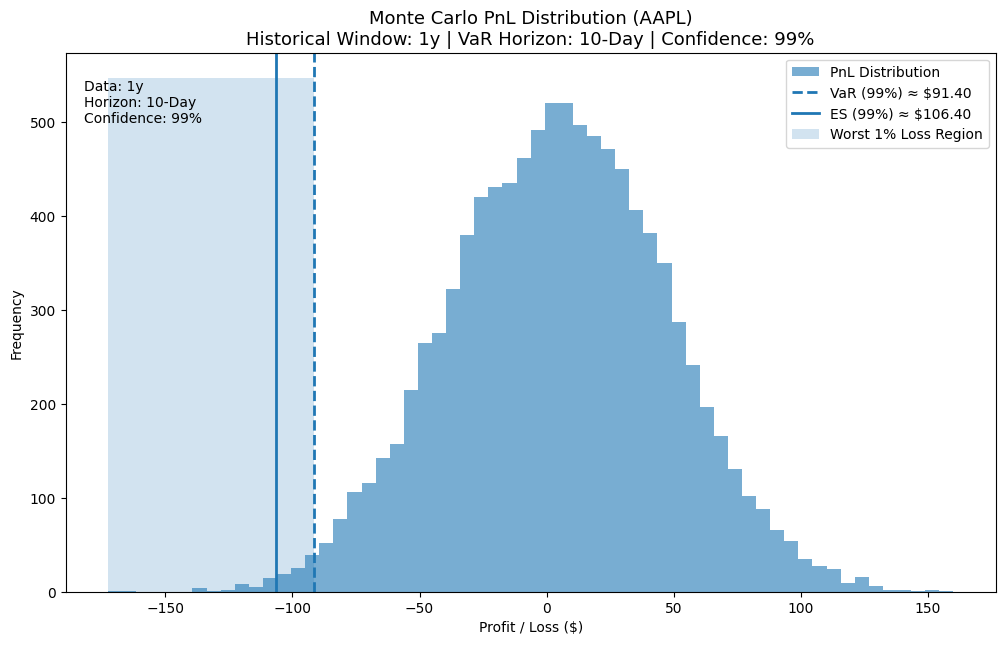

In [ ]:
#simulate over the next 10 days.
import matplotlib.pyplot as plt
plt.figure(figsize=(12,7))
period = "1y"
horizon = 10
confidence = 0.99
plt.hist(pnl, bins=60, alpha=0.6, label="PnL Distribution")

plt.axvline(-var, linestyle='--', linewidth=2,
            label=f"VaR (99%) ≈ ${var:.2f}")
losses = pnl[pnl < -var]
es = -losses.mean()
plt.axvline(-es, linestyle='-', linewidth=2,
            label=f"ES (99%) ≈ ${es:.2f}")
plt.fill_betweenx(
    y=[0, plt.gca().get_ylim()[1]],
    x1=min(pnl),
    x2=-var,
    alpha=0.2,
    label="Worst 1% Loss Region"
)
# Title with time info
plt.title(
    f"Monte Carlo PnL Distribution (AAPL)\n"
    f"Historical Window: {period} | VaR Horizon: {horizon}-Day | Confidence: 99%",
    fontsize=13
)
plt.xlabel("Profit / Loss ($)")
plt.ylabel("Frequency")
# Annotation box
plt.text(
    0.02, 0.95,
    f"Data: {period}\nHorizon: {horizon}-Day\nConfidence: 99%",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)
plt.legend()
plt.show()

Horizon test for 10 day

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
ticker = "AAPL"
stock_prices = yf.download(
    ticker,
    period="1y",
    interval="1d",
    auto_adjust=True
)["Close"]
# Make sure it is a single Series
if isinstance(stock_prices, pd.DataFrame):
    stock_prices = stock_prices[ticker]
returns = stock_prices.pct_change().dropna()
mu = returns.mean().item() if hasattr(returns.mean(), "item") else returns.mean()
sigma = returns.std().item() if hasattr(returns.std(), "item") else returns.std()
current_price = stock_prices.iloc[-1].item() if hasattr(stock_prices.iloc[-1], "item") else stock_prices.iloc[-1]
shares = 10
def monte_carlo_var_single(
    mu,
    sigma,
    current_price,
    shares,
    n_sim=10000,
    confidence=0.99,
    horizon=10
):
    simulated_returns = np.random.normal(
        loc=mu * horizon,
        scale=sigma * np.sqrt(horizon),
        size=n_sim
    )
    simulated_prices = current_price * (1 + simulated_returns)
    pnl = (simulated_prices - current_price) * shares
    var = -np.percentile(pnl, (1 - confidence) * 100)
    return var, pnl
var, pnl = monte_carlo_var_single(
    mu=mu,
    sigma=sigma,
    current_price=current_price,
    shares=shares,
    n_sim=10000,
    confidence=0.99,
    horizon=1
)
print("Current price:", current_price)
print("Mean daily return:", mu)
print("Daily volatility:", sigma)
print("Portfolio value:", current_price * shares)
print("Monte Carlo VaR 99%:", var)

[*********************100%***********************]  1 of 1 completed

Current price: 287.5199890136719
Mean daily return: 0.001600861190750294
Daily volatility: 0.014671681394415013
Portfolio value: 2875.1998901367188
Monte Carlo VaR 99%: 92.73417946816005


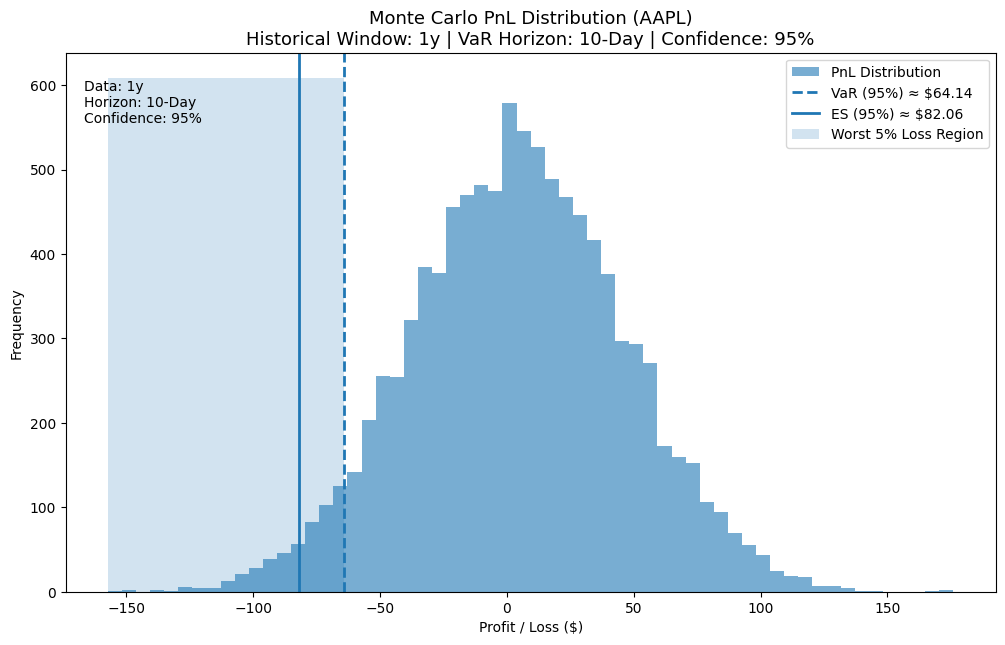

In [ ]:
#simulate over the next 10 days.
import matplotlib.pyplot as plt
plt.figure(figsize=(12,7))
period = "1y"
horizon = 10
confidence = 0.95
plt.hist(pnl, bins=60, alpha=0.6, label="PnL Distribution")

plt.axvline(-var, linestyle='--', linewidth=2,
            label=f"VaR (95%) ≈ ${var:.2f}")
losses = pnl[pnl < -var]
es = -losses.mean()
plt.axvline(-es, linestyle='-', linewidth=2,
            label=f"ES (95%) ≈ ${es:.2f}")
plt.fill_betweenx(
    y=[0, plt.gca().get_ylim()[1]],
    x1=min(pnl),
    x2=-var,
    alpha=0.2,
    label="Worst 5% Loss Region"
)
# Title with time info
plt.title(
    f"Monte Carlo PnL Distribution (AAPL)\n"
    f"Historical Window: {period} | VaR Horizon: {horizon}-Day | Confidence: 95%",
    fontsize=13
)
plt.xlabel("Profit / Loss ($)")
plt.ylabel("Frequency")
# Annotation box
plt.text(
    0.02, 0.95,
    f"Data: {period}\nHorizon: {horizon}-Day\nConfidence: 95%",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)
plt.legend()
plt.show()

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
ticker = "AAPL"
stock_prices = yf.download(
    ticker,
    period="1y",
    interval="1d",
    auto_adjust=True
)["Close"]
# Make sure it is a single Series
if isinstance(stock_prices, pd.DataFrame):
    stock_prices = stock_prices[ticker]
returns = stock_prices.pct_change().dropna()
mu = returns.mean().item() if hasattr(returns.mean(), "item") else returns.mean()
sigma = returns.std().item() if hasattr(returns.std(), "item") else returns.std()
current_price = stock_prices.iloc[-1].item() if hasattr(stock_prices.iloc[-1], "item") else stock_prices.iloc[-1]
shares = 10
def monte_carlo_var_single(
    mu,
    sigma,
    current_price,
    shares,
    n_sim=10000,
    confidence=0.95,
    horizon=10
):
    simulated_returns = np.random.normal(
        loc=mu * horizon,
        scale=sigma * np.sqrt(horizon),
        size=n_sim
    )
    simulated_prices = current_price * (1 + simulated_returns)
    pnl = (simulated_prices - current_price) * shares
    var = -np.percentile(pnl, (1 - confidence) * 100)
    return var, pnl
var, pnl = monte_carlo_var_single(
    mu=mu,
    sigma=sigma,
    current_price=current_price,
    shares=shares,
    n_sim=10000,
    confidence=0.95,
    horizon=1
)
print("Current price:", current_price)
print("Mean daily return:", mu)
print("Daily volatility:", sigma)
print("Portfolio value:", current_price * shares)
print("Monte Carlo VaR 95%:", var)

[*********************100%***********************]  1 of 1 completed

Current price: 287.510009765625
Mean daily return: 0.001652663310861017
Daily volatility: 0.014677877468376035
Portfolio value: 2875.10009765625
Monte Carlo VaR 95%: 64.12692423504974


In [ ]:
#Testing for Option market.


In [ ]:
#Historical VAR